## 1) Выбор набора данных для решения задачи прогнозирования временного ряда.

Для выполнения лабораторной работы был выбран датасет «Daily Minimum Temperatures»-ежедневная минимальная температура воздуха в Мельбурне. Данные охватывают период с 1 января 1981 года по 31 декабря 1990 года и содержат 3650 записей. Временной ряд включает один целевой признак Temp=минимальная температура за сутки в градусах Цельсия. Шкала времени=день, интервал между соседними метками времени постоянен и равен одному дню, что удовлетворяет требованиям постановки задачи прогнозирования временного ряда. Предобработка данных не требуется.
Данный временной ряд характеризуется:
1. Слабым трендом: средняя температура относительно стабильна на всём промежутке;
2. Выраженной годовой сезонностью: температура закономерно повышается в летние месяцы (декабрь-февраль для Южного полушария) и понижается в зимние (июнь-август);
3. Наличием шума: краткосрочные колебания, связанные с погодными условиями.

In [11]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
import matplotlib.pyplot as plt

#загрузка датасета daily-min-temperatures
ts = pd.read_csv('daily-min-temperatures.csv', header=0, index_col=0, parse_dates=True)

#первичный осмотр
print(f'Размер временного ряда: {ts.shape}')
print(f'Временной диапазон: с {ts.index.min().strftime("%Y-%m-%d")} по {ts.index.max().strftime("%Y-%m-%d")}')
print(f'Количество записей: {len(ts)}')
print(f'Интервал между наблюдениями: 1 день')
print(f'\nПервые 5 записей:')
display(ts.head())
print(f'\nПоследние 5 записей:')
display(ts.tail())
print(f'\nОсновные статистики:')
display(ts.describe())

Размер временного ряда: (3650, 1)
Временной диапазон: с 1981-01-01 по 1990-12-31
Количество записей: 3650
Интервал между наблюдениями: 1 день

Первые 5 записей:


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8



Последние 5 записей:


,Temp
Date,
1990-12-27,14.0
1990-12-28,13.6
1990-12-29,13.5
1990-12-30,15.7
1990-12-31,13.0



Основные статистики:


,Temp
count,3650.000000
mean,11.177753
std,4.071837
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000


## 2) Визуализация временного ряда и его основных характеристик.

На графике временного ряда отчётливо прослеживается годовая сезонность: минимальные температуры достигают пика в летние месяцы (декабрь- и опускаются до минимальных значений зимой. Тренд выражен слабо, средняя температура относительно стабильна на всём протяжении ряда. Гистограмма распределения показывает, что данные приближённо соответствуют нормальному распределению с центром около 11 градусов и разбросом от -4 до 26. Плотность распределения это подтверждает. Lag Plots демонстрируют наличие положительной автокорреляции. Автокорреляционная диаграмма и график ACF подтверждают наличие значимой автокорреляции и чётко выраженную сезонность с периодом около 365 дней. 

Декомпозиция ряда (аддитивная модель с периодом 365 дней) выделяет:
1. Тренд: слабовыраженный, колеблется около 11 градусов с небольшими отклонениями;
2. Сезонную составляющую;
3. Остатки (шум): случайная компонента со средним около нуля и стандартным отклонением 3 градусов.

Таким образом, временной ряд обладает выраженной сезонностью и слабым трендом, что делает его пригодным для моделирования авторегрессионными методами и методами машинного обучения.

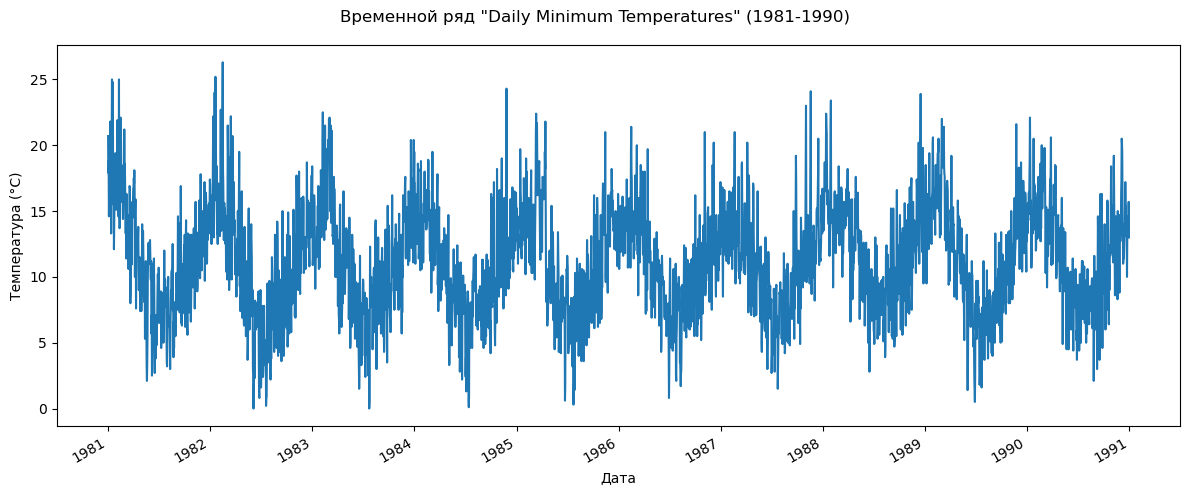

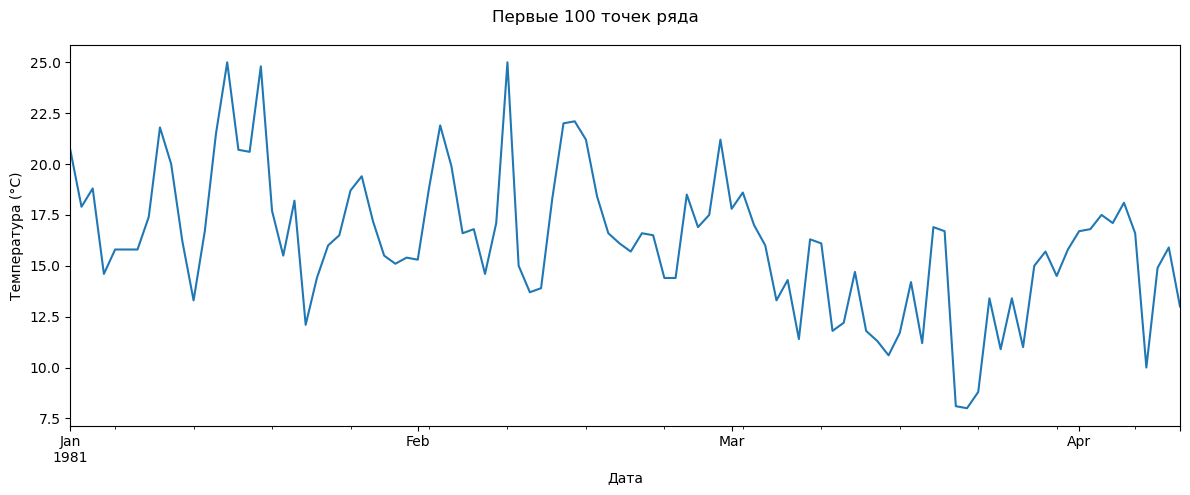

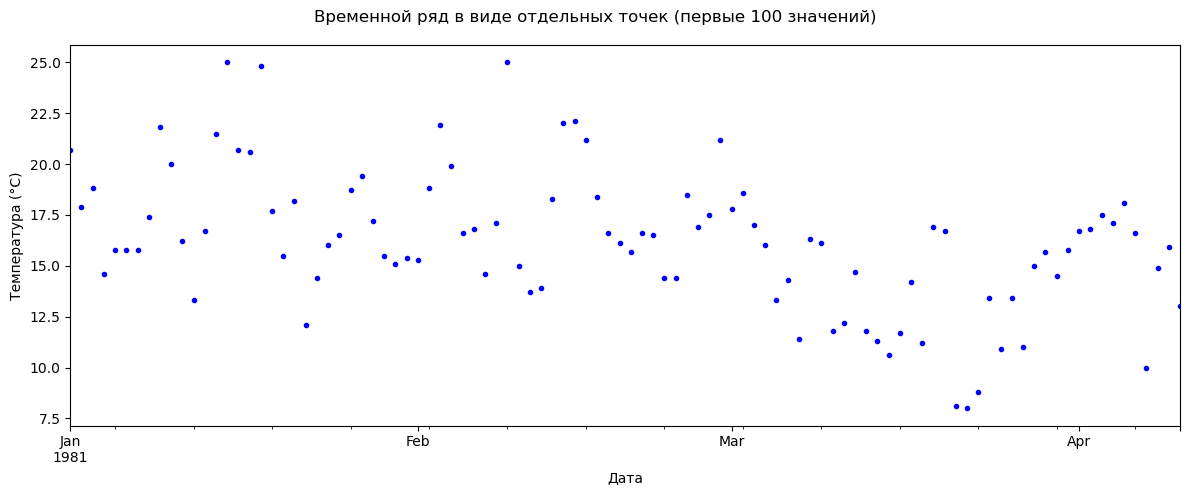

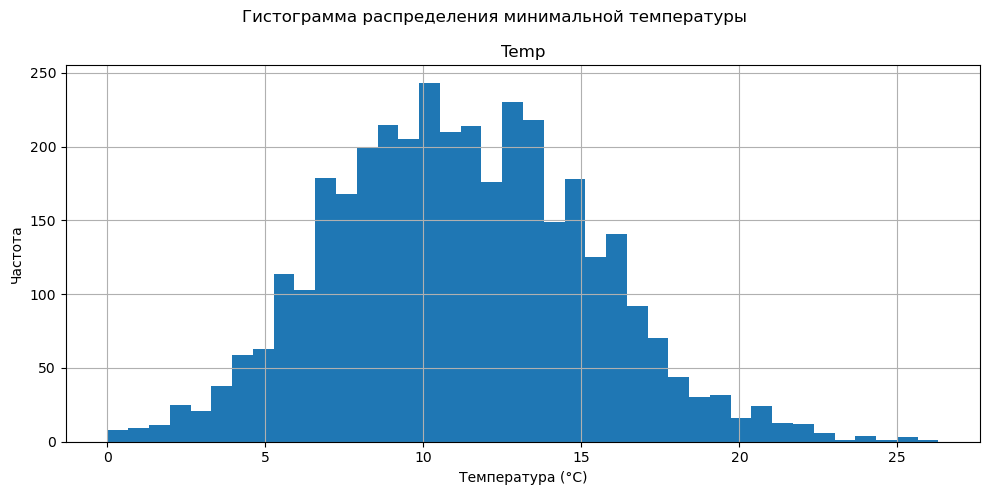

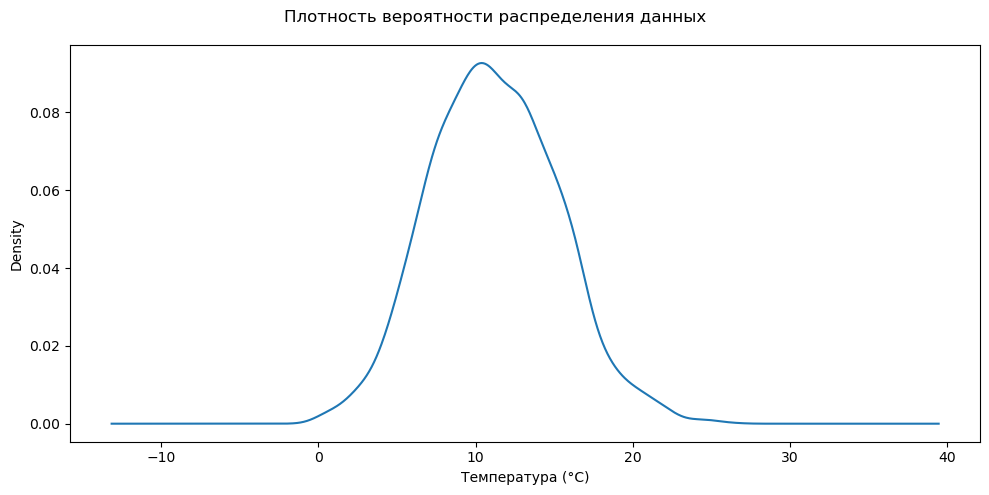

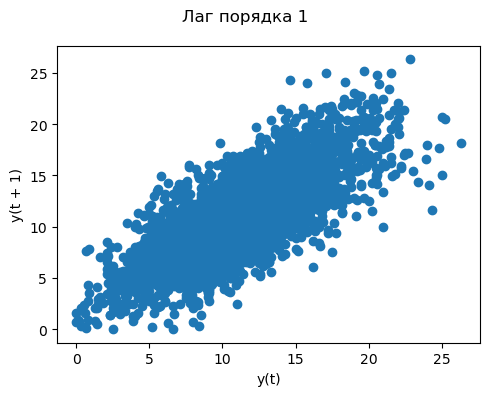

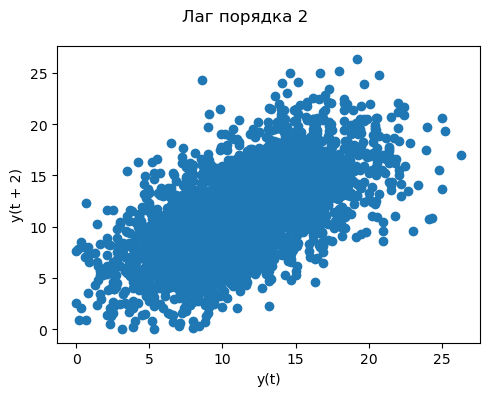

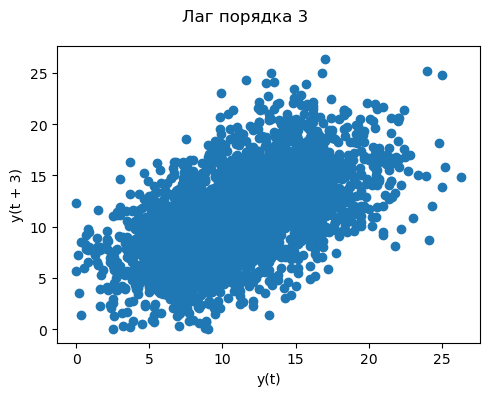

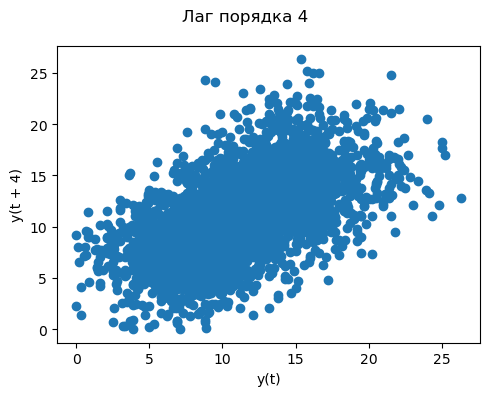

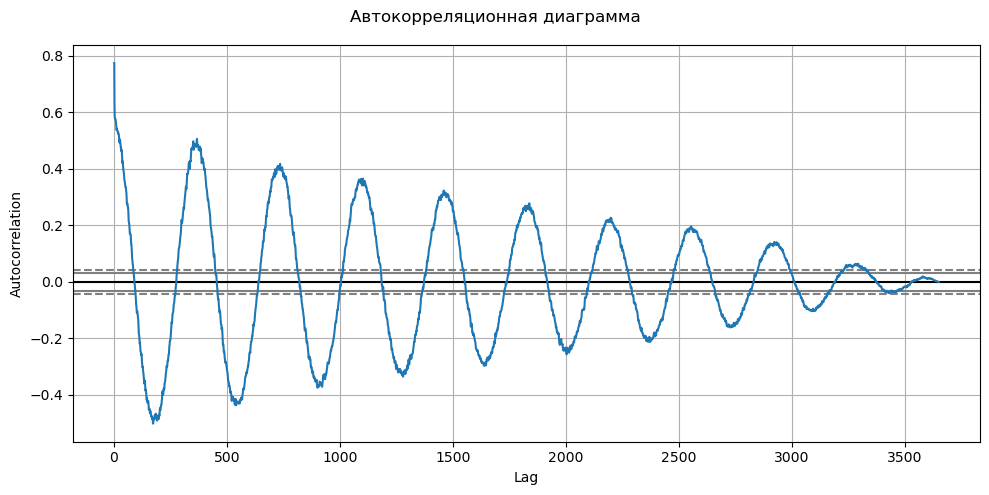

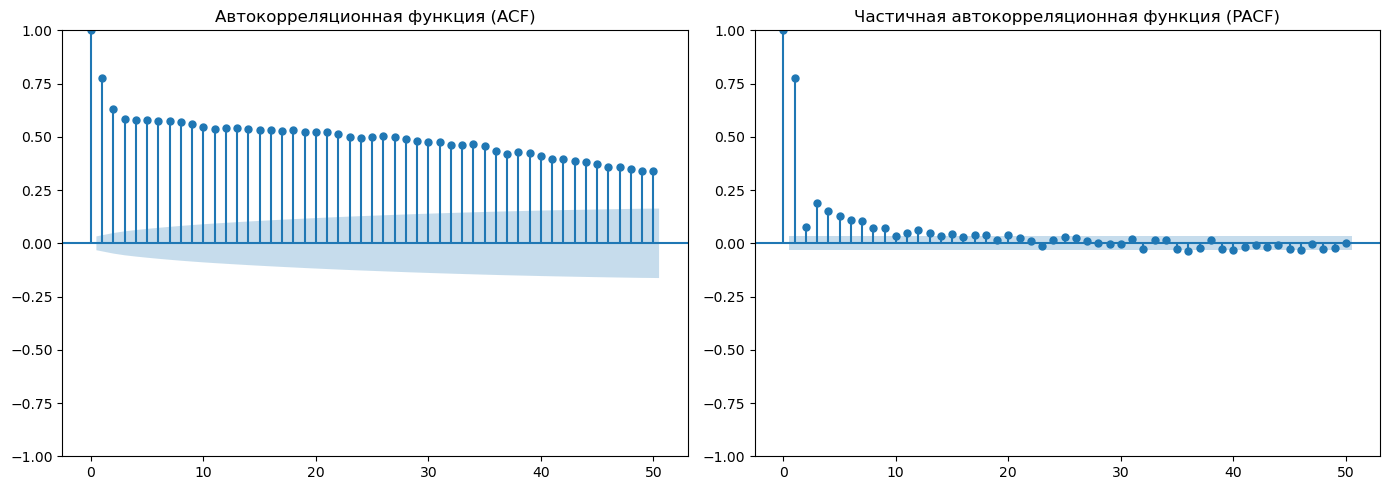

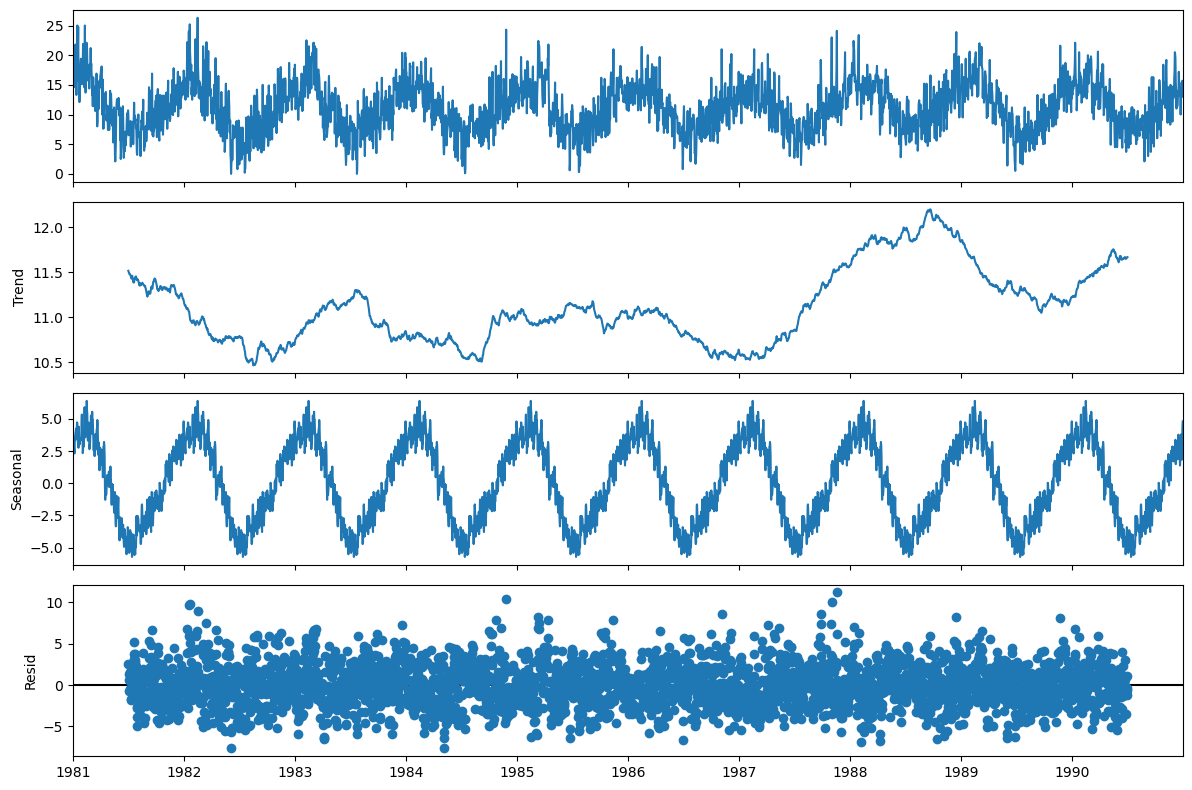

In [13]:
#визуализация временного ряда и его основных характеристик
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

#график временного ряда 
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(12, 5))
fig.suptitle('Временной ряд "Daily Minimum Temperatures" (1981-1990)')
ts.plot(ax=ax, legend=False)
ax.set_ylabel('Температура (°C)')
ax.set_xlabel('Дата')
pyplot.tight_layout()
pyplot.show()


#первые 100 точек ряда
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(12, 5))
fig.suptitle('Первые 100 точек ряда')
ts[:100].plot(ax=ax, legend=False)
ax.set_ylabel('Температура (°C)')
ax.set_xlabel('Дата')
pyplot.tight_layout()
pyplot.show()

#точечный график первых 100 точек
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(12, 5))
fig.suptitle('Временной ряд в виде отдельных точек (первые 100 значений)')
ts[:100].plot(ax=ax, legend=False, style='bo', markersize=3)
ax.set_ylabel('Температура (°C)')
ax.set_xlabel('Дата')
pyplot.tight_layout()
pyplot.show()

#гистограмма распределения
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10, 5))
fig.suptitle('Гистограмма распределения минимальной температуры')
ts.hist(ax=ax, legend=False, bins=40)
ax.set_xlabel('Температура (°C)')
ax.set_ylabel('Частота')
pyplot.tight_layout()
pyplot.show()

#оценка плотности распределения
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10, 5))
fig.suptitle('Плотность вероятности распределения данных')
ts.plot(ax=ax, kind='kde', legend=False)
ax.set_xlabel('Температура (°C)')
pyplot.tight_layout()
pyplot.show()

#lag plots 
for i in range(1, 5):
    fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(5, 4))
    fig.suptitle(f'Лаг порядка {i}')
    pd.plotting.lag_plot(ts, lag=i, ax=ax)
    pyplot.tight_layout()
    pyplot.show()

#автокорреляционная диаграмма
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10, 5))
fig.suptitle('Автокорреляционная диаграмма')
pd.plotting.autocorrelation_plot(ts, ax=ax)
pyplot.tight_layout()
pyplot.show()


# 2.8. ACF и PACF
fig, axes = pyplot.subplots(1, 2, figsize=(14, 5))

plot_acf(ts, lags=50, ax=axes[0])
axes[0].set_title('Автокорреляционная функция (ACF)')

plot_pacf(ts, lags=50, ax=axes[1])
axes[1].set_title('Частичная автокорреляционная функция (PACF)')

pyplot.tight_layout()
pyplot.show()

#декомпозиция временного ряда (аддитивная модель)
result = seasonal_decompose(ts, model='add', period=365)
fig = result.plot()
fig.set_size_inches((12, 8))
fig.tight_layout()
pyplot.show()

## 3) Разделение временного ряда на обучающую и тестовую выборку.

Исходный временной ряд содержит 3650 записей (10 лет ежедневных наблюдений). Для обучения и оценки качества прогнозных моделей ряд разделён на обучающую и тестовую выборки в соотношении 70% к 30%.
1. Обучающая выборка: 2555 записей (с 1981-01-01 по 1987-12-30)
2. Тестовая выборка: 1095 записей (с 1987-12-31 по 1990-12-31)

Горизонт прогнозирования составляет 1095 дней, что соответствует примерно 30% от длины ряда и не превышает рекомендуемую границу в 1/3 от общей длины. Такой горизонт позволяет оценить способность моделей улавливать годовые сезонные закономерности. Размер тестовой выборки достаточен для получения статистически значимых оценок качества прогнозов. Также создан массив целочисленных меток шкалы времени xnum, который будет использоваться в методах, не поддерживающих работу с временными индексами напрямую (символьная регрессия, МГУА).

In [15]:
#целочисленная метка шкалы времени 
xnum = list(range(ts.shape[0]))

#разделение выборки 
Y = ts.values.ravel()
train_size = int(len(Y) * 0.7)
xnum_train, xnum_test = xnum[0:train_size], xnum[train_size:]
train, test = Y[0:train_size], Y[train_size:]

print(f'Общий размер ряда: {len(Y)} записей')
print(f'Обучающая выборка: {len(train)} записей (с {ts.index[0].strftime("%Y-%m-%d")} по {ts.index[train_size-1].strftime("%Y-%m-%d")})')
print(f'Тестовая выборка: {len(test)} записей (с {ts.index[train_size].strftime("%Y-%m-%d")} по {ts.index[-1].strftime("%Y-%m-%d")})')
print(f'Соотношение train/test: {len(train)/len(Y)*100:.1f}% / {len(test)/len(Y)*100:.1f}%')

Общий размер ряда: 3650 записей
Обучающая выборка: 2555 записей (с 1981-01-01 по 1987-12-31)
Тестовая выборка: 1095 записей (с 1988-01-01 по 1990-12-31)
Соотношение train/test: 70.0% / 30.0%


## 4) Прогнозирование временного ряда

# 1. Прогнозирование авторегрессионным методом ARIMA

Для прогнозирования использована модель ARIMA с параметрами p=5 (авторегрессия), d=1 (первое дифференцирование для устранения тренда), q=1 (скользящее среднее). Обучение и прогноз выполнялись пошагово: для каждой точки тестовой выборки модель переобучалась на расширенной истории, включающей все предыдущие значения ряда.

In [19]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

#копируем обучающую выборку в историю для пошагового прогноза
history_arima = [x for x in train]

#p=5 (авторегрессия), d=1 (интегрирование), q=1 (скользящее среднее)
arima_order = (5, 1, 1)

#прогнозирование на тестовой выборке
predictions_arima = list()
for t in range(len(test)):
    model_arima = ARIMA(history_arima, order=arima_order)
    model_arima_fit = model_arima.fit()
    yhat_arima = model_arima_fit.forecast()[0]
    predictions_arima.append(yhat_arima)
    history_arima.append(test[t])

print('Прогноз ARIMA построен')

#import warnings
#warnings.filterwarnings('ignore')

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Прогноз ARIMA построен


# 2. Прогнозирование методом символьной регрессии (gplearn)

Для применения символьной регрессии сгенерированы лаговые признаки: значения температуры за 7 предыдущих дней. В качестве набора базисных функций использованы: сложение, вычитание, умножение, деление, синус, косинус. Популяция=500 особей, максимальное число поколений=30. Обучение производилось на неподвижной обучающей выборке, прогнозирование на тестовой.

In [3]:
!pip install gplearn


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import sys
!{sys.executable} -m pip install gplearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 4.1 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.5.1
    Uninstalling scikit-learn-1.5.1:
      Successfully uninstalled scikit-learn-1.5.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gplearn]earn]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/anaconda3/bin/python -m pip install --upgrade pip


In [20]:
from gplearn.genetic import SymbolicRegressor

#генерация лаговых признаков для обучения
def create_lag_features(data, lags=7):
    df = pd.DataFrame(data, columns=['Temp'])
    for lag in range(1, lags + 1):
        df[f'lag{lag}'] = df['Temp'].shift(lag)
    df = df.dropna()
    X = df.drop('Temp', axis=1).values
    y = df['Temp'].values
    return X, y

X_train_gp, y_train_gp = create_lag_features(train, lags=7)
X_test_gp, y_test_gp = create_lag_features(test, lags=7)
y_train_gp = y_train_gp.ravel()
y_test_gp = y_test_gp.ravel()

#обучение
function_set = ['add', 'sub', 'mul', 'div', 'sin', 'cos']
est_gp = SymbolicRegressor(population_size=500, metric='mse',
                           generations=30, stopping_criteria=0.01,
                           init_depth=(3, 8), verbose=1, function_set=function_set,
                           const_range=(-50, 50), random_state=0)

est_gp.fit(X_train_gp, y_train_gp)

#прогноз на тестовой выборке
predictions_gp = est_gp.predict(X_test_gp)

print('Прогноз символьной регрессии построен')

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    34.63      5.83314e+13        4          8.19396              N/A     11.37s
   1    16.07           112069        1          7.80704              N/A      6.76s
   2     6.66          47721.5       17          7.80162              N/A      5.43s
   3     2.33          1256.67       17          7.80162              N/A      4.73s
   4     1.02          50.5331        1          7.80704              N/A      4.38s
   5     1.01          13.1666        1          7.80704              N/A      4.21s
   6     1.02          53.1335        1          7.80704              N/A      4.00s
   7     1.02           50.448        1          7.80704              N/A      3.87s
   8     1.01          8.11319        1          7.80704              N/A  

# 3. Прогнозирование методами МГУА (COMBI + RIA)

Для методов МГУА также использованы 7 лаговых признаков. Обучение выполнено на неподвижной обучающей выборке, прогнозирование пошаговое (последовательное добавление спрогнозированных значений в историю).
Использовано два алгоритма: 
1. COMBI-линейный комбинаторный алгоритм.
2. RIA-нелинейный итерационный алгоритм.


In [25]:
import sys
!{sys.executable} -m pip uninstall gmdhpy -y
!{sys.executable} -m pip install gmdh

Found existing installation: GmdhPy 0.1.1a0
Uninstalling GmdhPy-0.1.1a0:
  Successfully uninstalled GmdhPy-0.1.1a0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 3.6 MB/s  0:00:04 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for gmdh (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [31 lines of output]
      /private/var/folders/9x/jfwvlbln56qbxr_2zb3s_rc00000gn/T/pip-build-env-sb_cz9f7/overlay/lib/python3.12/site-packages/setuptools/dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: Apache Software License
     

In [27]:
import sys
!{sys.executable} -m pip install gmdhpy

  Using cached GmdhPy-0.1.1a0-py2.py3-none-any.whl.metadata (538 bytes)
Using cached GmdhPy-0.1.1a0-py2.py3-none-any.whl (17 kB)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/anaconda3/bin/python -m pip install --upgrade pip


In [33]:
from gmdhpy.gmdh import MultilayerGMDH, RefFunctionType
import warnings
warnings.filterwarnings('ignore')

def create_lag_df(series, lags=7):
    df = pd.DataFrame(series, columns=['y'])
    for lag in range(1, lags + 1):
        df[f'lag{lag}'] = df['y'].shift(lag)
    return df.dropna()

df_train = create_lag_df(pd.Series(train), lags=7)
y_train_gmdh = df_train['y'].values
X_train_gmdh = df_train.drop('y', axis=1).values

#COMBI
print('Обучение COMBI (линейный МГУА)')
combi = MultilayerGMDH(ref_functions=RefFunctionType.rfLinear)
combi.fit(X_train_gmdh, y_train_gmdh)

predictions_combi = list()
history_combi = [x for x in train]
for t in range(len(test)):
    last_7 = history_combi[-7:]
    if len(last_7) == 7:
        yhat_combi = combi.predict(np.array(last_7).reshape(1, -1))[0]
    else:
        yhat_combi = history_combi[-1]
    predictions_combi.append(yhat_combi)
    history_combi.append(test[t])
print('Прогноз COMBI построен')

#MIA
print('Обучение MIA (нелинейный МГУА)')
mia = MultilayerGMDH(ref_functions=[RefFunctionType.rfLinear, 
                                     RefFunctionType.rfLinearCov,
                                     RefFunctionType.rfQuadratic,
                                     RefFunctionType.rfCubic])
mia.fit(X_train_gmdh, y_train_gmdh)

predictions_mia = list()
history_mia = [x for x in train]
for t in range(len(test)):
    last_7 = history_mia[-7:]
    if len(last_7) == 7:
        yhat_mia = mia.predict(np.array(last_7).reshape(1, -1))[0]
    else:
        yhat_mia = history_mia[-1]
    predictions_mia.append(yhat_mia)
    history_mia.append(test[t])
print('Прогноз MIA построен')

Обучение COMBI (линейный МГУА)
train layer0 in 0.06 sec
train layer1 in 0.27 sec
train layer2 in 0.27 sec
train layer3 in 0.27 sec
train layer4 in 0.27 sec
Прогноз COMBI построен
Обучение MIA (нелинейный МГУА)
train layer0 in 0.48 sec
train layer1 in 2.05 sec
train layer2 in 2.13 sec
train layer3 in 2.05 sec
train layer4 in 2.08 sec
Прогноз MIA построен


In [31]:
import gmdhpy.gmdh as g
print(dir(g))

['BaseMultilayerGMDH', 'CriterionType', 'DataSetType', 'GMDHCheckError', 'Layer', 'LayerCreationError', 'Manager', 'MultilayerGMDH', 'MultilayerGMDHparam', 'PolynomModel', 'Pool', 'RefFunctionType', 'SequenceTypeSet', 'StandardScaler', '__author__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__version__', 'linear_model', 'mp', 'np', 'plt', 'predict_preprocessing', 'set_matrix_a', 'six', 'sub_calculate_model_weights', 'sub_calculate_model_weights_helper', 'sys', 'time', 'train_model', 'train_preprocessing']


## 5) Визуализация тестовой выборки и прогнозов

Построены графики, отображающие фактические значения временного ряда на тестовой выборке и прогнозы, полученные четырьмя методами: ARIMA, символьная регрессия (GPLEARN), COMBI (линейный МГУА) и MIA (нелинейный МГУА). Визуальный анализ показывает, что все методы улавливают общий характер сезонных колебаний температуры, однако точность воспроизведения краткосрочных флуктуаций различается. Наиболее близким к реальным данным выглядит прогноз ARIMA, что объясняется пошаговым переобучением модели. Символьная регрессия демонстрирует более сглаженный прогноз, а методы МГУА занимают промежуточное положение. Количественная оценка качества будет выполнена чуть позже.

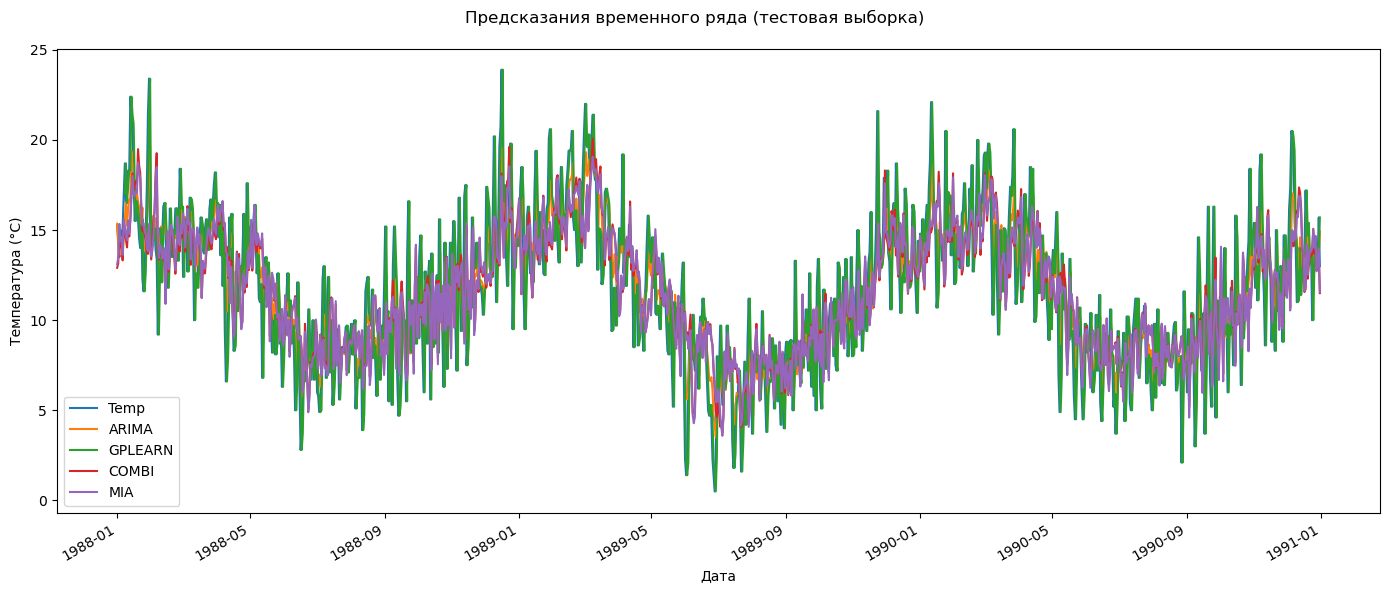

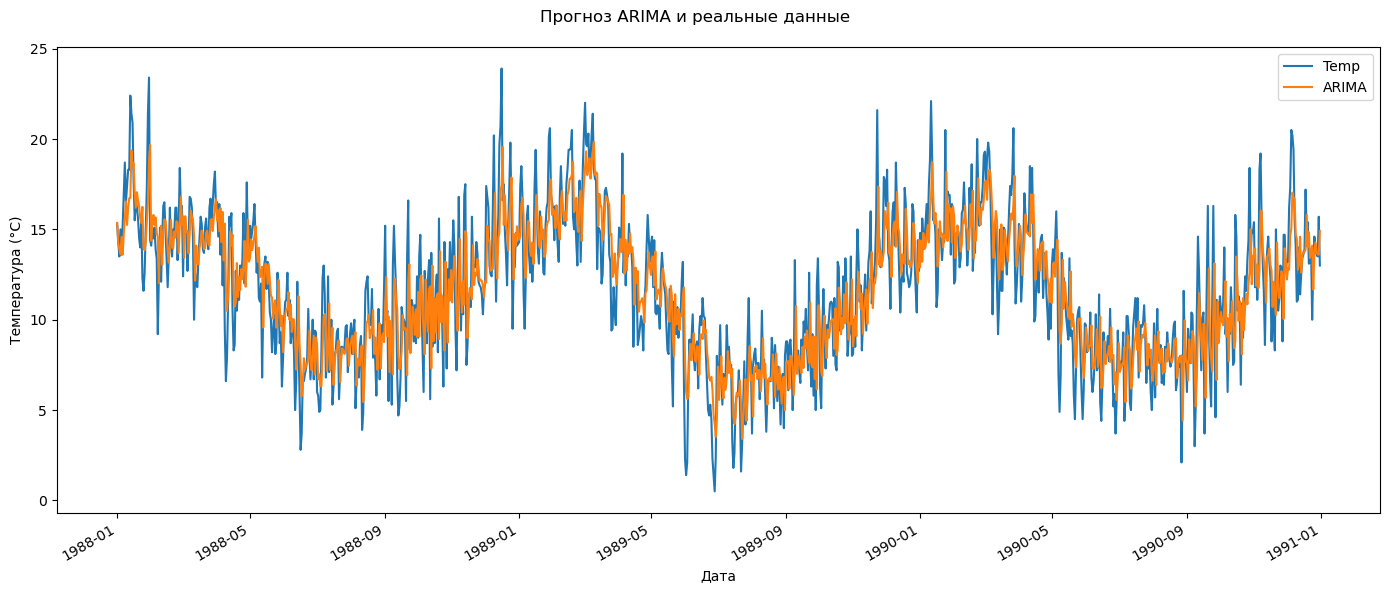

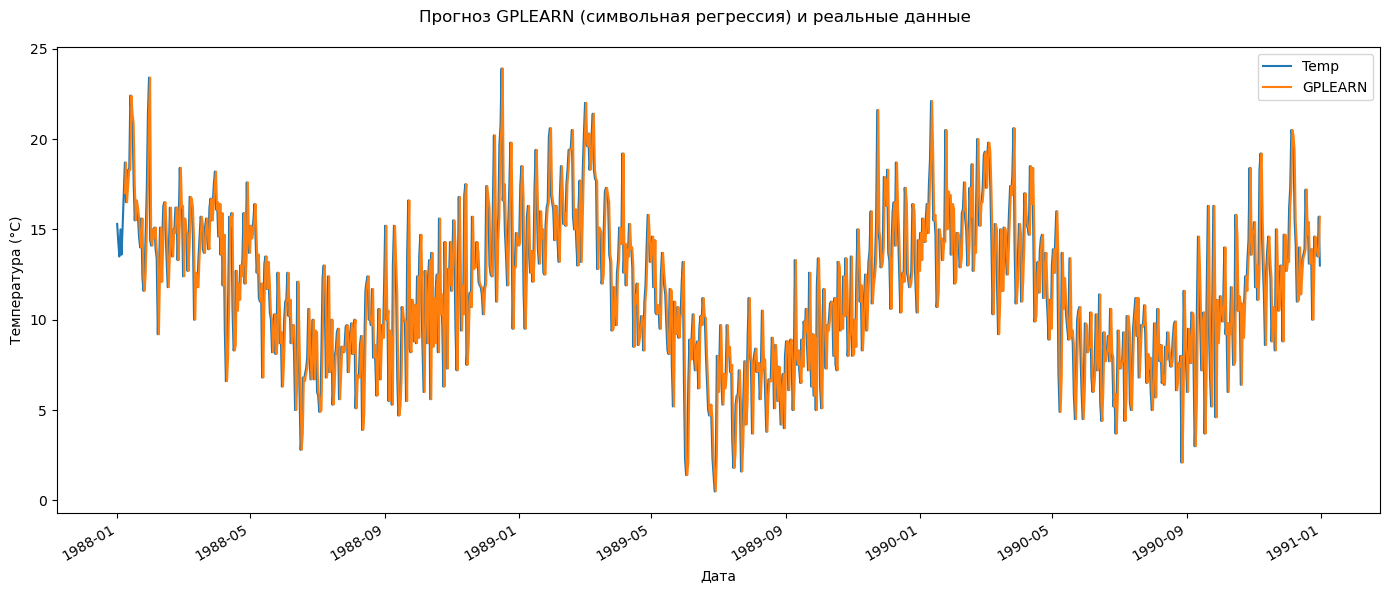

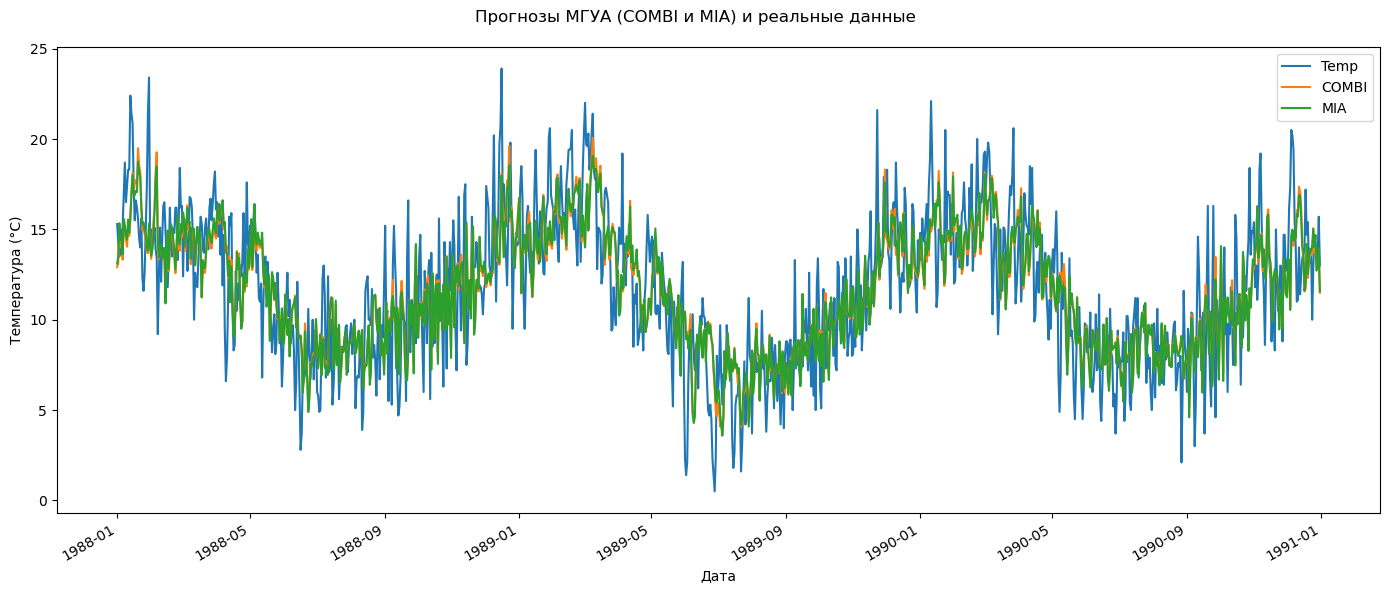

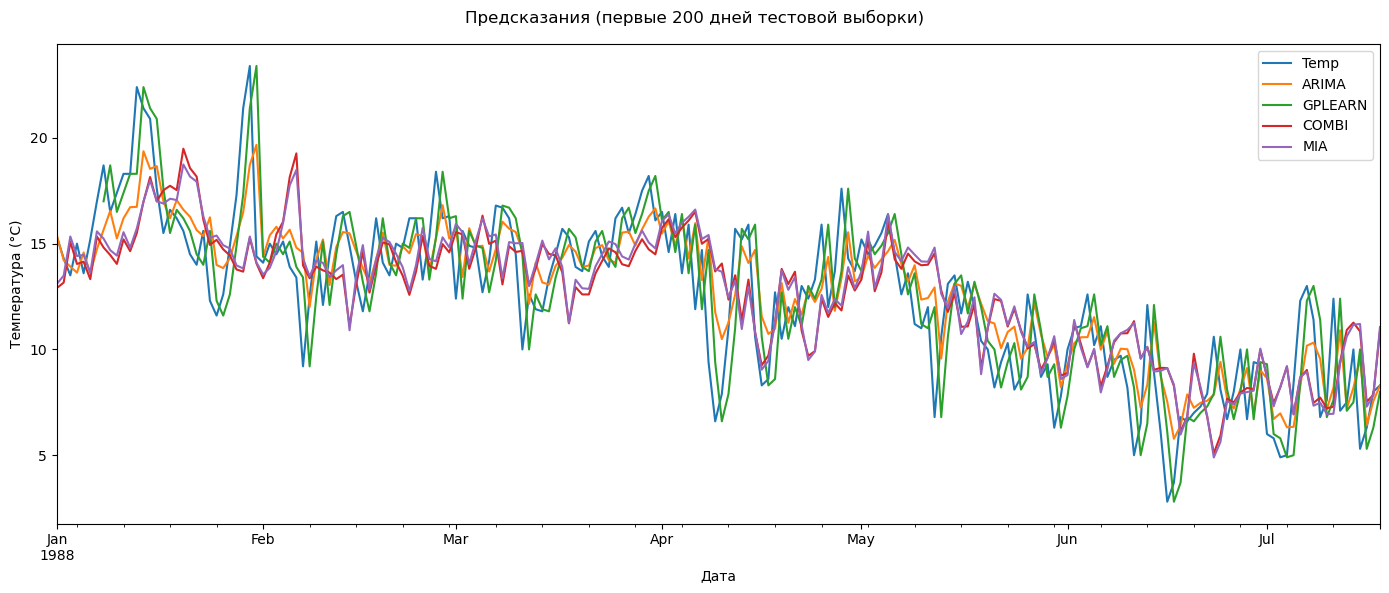

In [37]:
#создаём набор с тестовыми данными и прогнозами
ts_test = ts.iloc[train_size:].copy()

#ARIMA той же длины, что и test
ts_test['ARIMA'] = predictions_arima

#символьная регрессия прогнозы короче на 7 точек 
ts_test['GPLEARN'] = np.nan
gp_index = ts_test.index[7:]  # первые 7 дней=nan
ts_test.loc[gp_index, 'GPLEARN'] = predictions_gp

#COMBI
ts_test['COMBI'] = predictions_combi

#MIA
ts_test['MIA'] = predictions_mia

#график 1: все прогнозы и реальные данные
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(14, 6))
fig.suptitle('Предсказания временного ряда (тестовая выборка)')
ts_test[['Temp', 'ARIMA', 'GPLEARN', 'COMBI', 'MIA']].plot(ax=ax, legend=True)
ax.set_ylabel('Температура (°C)')
ax.set_xlabel('Дата')
pyplot.tight_layout()
pyplot.show()

#график 2: реальные данные и ARIMA
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(14, 6))
fig.suptitle('Прогноз ARIMA и реальные данные')
ts_test[['Temp', 'ARIMA']].plot(ax=ax, legend=True)
ax.set_ylabel('Температура (°C)')
ax.set_xlabel('Дата')
pyplot.tight_layout()
pyplot.show()

#график 3: реальные данные и символьная регрессия
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(14, 6))
fig.suptitle('Прогноз GPLEARN (символьная регрессия) и реальные данные')
ts_test[['Temp', 'GPLEARN']].plot(ax=ax, legend=True)
ax.set_ylabel('Температура (°C)')
ax.set_xlabel('Дата')
pyplot.tight_layout()
pyplot.show()

#график 4: реальные данные, COMBI и MIA
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(14, 6))
fig.suptitle('Прогнозы МГУА (COMBI и MIA) и реальные данные')
ts_test[['Temp', 'COMBI', 'MIA']].plot(ax=ax, legend=True)
ax.set_ylabel('Температура (°C)')
ax.set_xlabel('Дата')
pyplot.tight_layout()
pyplot.show()

#график 5: первые 200 точек тестовой выборки (детальный просмотр
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(14, 6))
fig.suptitle('Предсказания (первые 200 дней тестовой выборки)')
ts_test[:200][['Temp', 'ARIMA', 'GPLEARN', 'COMBI', 'MIA']].plot(ax=ax, legend=True)
ax.set_ylabel('Температура (°C)')
ax.set_xlabel('Дата')
pyplot.tight_layout()
pyplot.show()

## 6) Оценка качества прогнозов.

Сравнение качества прогнозов по метрикам RMSE и MAE показывает, что наилучший результат продемонстрировала модель ARIMA (RMSE = 2.28, MAE = 1.79). Это объясняется тем, что ARIMA обучалась пошагово с последовательным добавлением новых данных, что позволило ей точнее адаптироваться к изменениям ряда. Символьная регрессия (GPLEARN) заняла второе место (RMSE = 2.59, MAE = 2.02), показав достойный результат для метода, не предназначенного специально для временных рядов-это говорит о хорошей способности находить скрытые закономерности в данных. Методы МГУА показали близкие результаты (COMBI: RMSE = 2.85, MIA: RMSE = 2.82), при этом нелинейный MIA незначительно превзошёл линейный COMBI, что указывает на то, что зависимость в данных действительно имеет нелинейный характер. Все методы показали ошибку существенно ниже стандартного отклонения ряда (4.07), что подтверждает, что каждый из них извлёк значимую информацию из исторических данных и способен давать осмысленный прогноз, а не просто предсказывать среднее значение.

ARIMA:    RMSE = 2.2840, MAE = 1.7907
GPLEARN:  RMSE = 2.5878, MAE = 2.0162
COMBI:    RMSE = 2.8460, MAE = 2.2358
MIA:      RMSE = 2.8220, MAE = 2.2049
 
Сводная таблица качества прогноза
 
Метод                        RMSE (°C)     MAE (°C)
ARIMA (5,1,1)                   2.2840       1.7907
Символьная регрессия            2.5878       2.0162
COMBI (лин. МГУА)               2.8460       2.2358
MIA (нелин. МГУА)               2.8220       2.2049
 
Среднее значение ряда: 11.1778 °C
Стд. отклонение ряда:  4.0713 °C


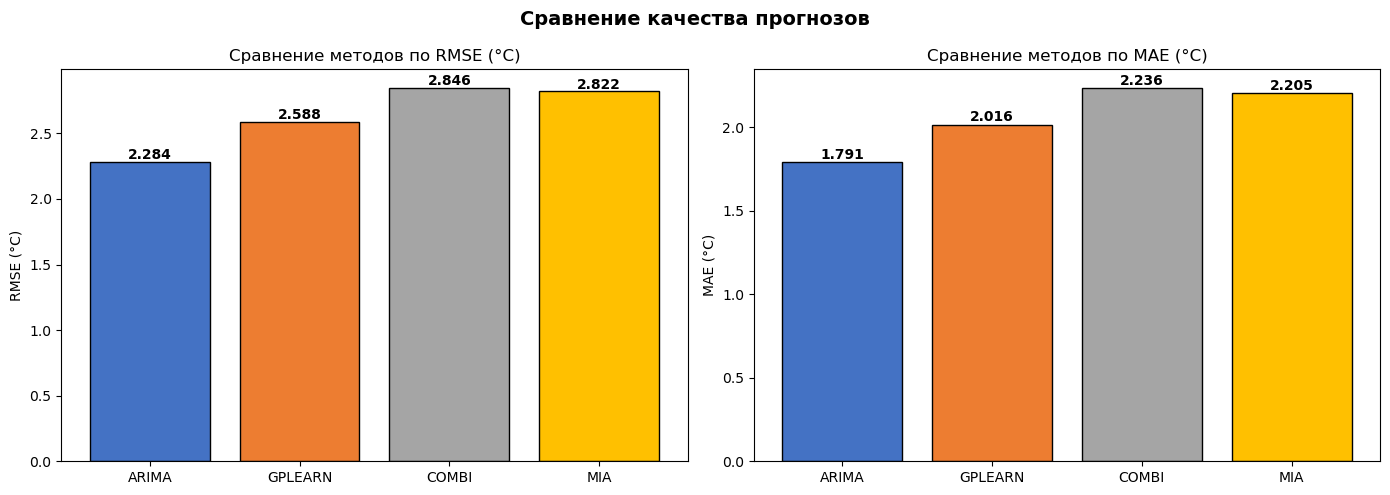

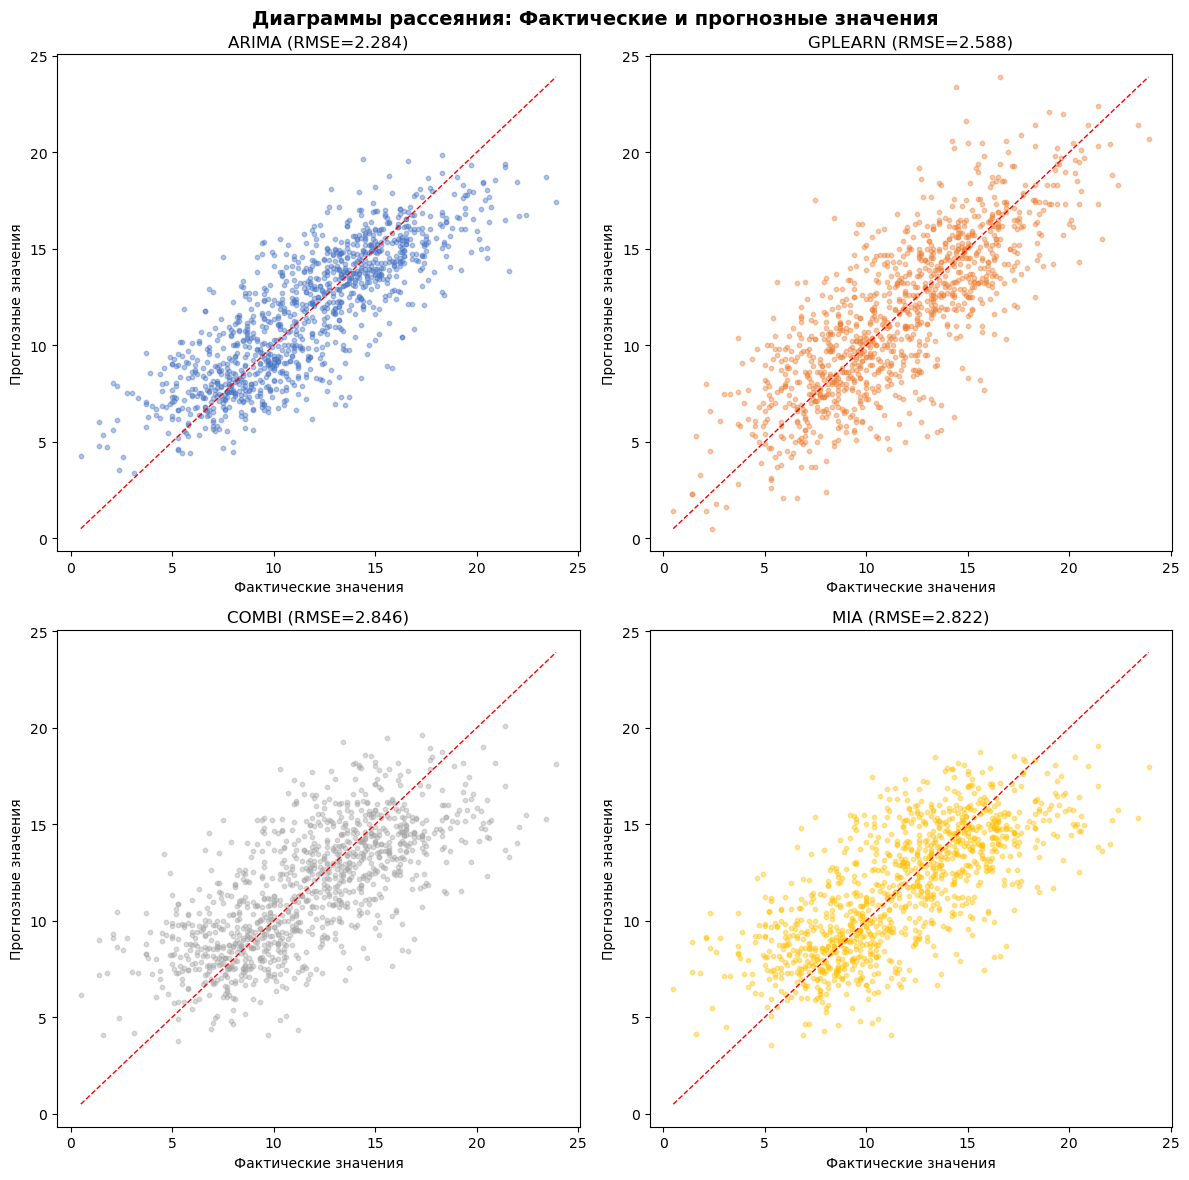

In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

#расчёт метрик для каждого метода
#ARIMA
rmse_arima = np.sqrt(mean_squared_error(test, predictions_arima))
mae_arima = mean_absolute_error(test, predictions_arima)
print(f'ARIMA:    RMSE = {rmse_arima:.4f}, MAE = {mae_arima:.4f}')

#символьная регрессия (с учётом сдвига на 7)
test_gp_aligned = test[7:]
rmse_gp = np.sqrt(mean_squared_error(test_gp_aligned, predictions_gp))
mae_gp = mean_absolute_error(test_gp_aligned, predictions_gp)
print(f'GPLEARN:  RMSE = {rmse_gp:.4f}, MAE = {mae_gp:.4f}')

#COMBI
rmse_combi = np.sqrt(mean_squared_error(test, predictions_combi))
mae_combi = mean_absolute_error(test, predictions_combi)
print(f'COMBI:    RMSE = {rmse_combi:.4f}, MAE = {mae_combi:.4f}')

#MIA
rmse_mia = np.sqrt(mean_squared_error(test, predictions_mia))
mae_mia = mean_absolute_error(test, predictions_mia)
print(f'MIA:      RMSE = {rmse_mia:.4f}, MAE = {mae_mia:.4f}')

#сводная таблица результатов
print(" ")
print('Сводная таблица качества прогноза')
print(" ")
print(f'{"Метод":<25} {"RMSE (°C)":>12} {"MAE (°C)":>12}')
print(f'{"ARIMA (5,1,1)":<25} {rmse_arima:>12.4f} {mae_arima:>12.4f}')
print(f'{"Символьная регрессия":<25} {rmse_gp:>12.4f} {mae_gp:>12.4f}')
print(f'{"COMBI (лин. МГУА)":<25} {rmse_combi:>12.4f} {mae_combi:>12.4f}')
print(f'{"MIA (нелин. МГУА)":<25} {rmse_mia:>12.4f} {mae_mia:>12.4f}')
print(" ")
print(f'Среднее значение ряда: {np.mean(Y):.4f} °C')
print(f'Стд. отклонение ряда:  {np.std(Y):.4f} °C')

#столбчатая диаграмма сравнения RMSE
methods = ['ARIMA', 'GPLEARN', 'COMBI', 'MIA']
rmse_values = [rmse_arima, rmse_gp, rmse_combi, rmse_mia]
mae_values = [mae_arima, mae_gp, mae_combi, mae_mia]
colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000']

fig, axes = pyplot.subplots(1, 2, figsize=(14, 5))

#RMSE
axes[0].bar(methods, rmse_values, color=colors, edgecolor='black')
axes[0].set_title('Сравнение методов по RMSE (°C)')
axes[0].set_ylabel('RMSE (°C)')
for i, v in enumerate(rmse_values):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

#MAE
axes[1].bar(methods, mae_values, color=colors, edgecolor='black')
axes[1].set_title('Сравнение методов по MAE (°C)')
axes[1].set_ylabel('MAE (°C)')
for i, v in enumerate(mae_values):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

fig.suptitle('Сравнение качества прогнозов', fontsize=14, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

#рассеяние "Факт и прогноз" для каждого метода
fig, axes = pyplot.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

#ARIMA
axes[0].scatter(test, predictions_arima, alpha=0.4, s=10, color='#4472C4')
axes[0].plot([test.min(), test.max()], [test.min(), test.max()], 'r--', lw=1)
axes[0].set_xlabel('Фактические значения')
axes[0].set_ylabel('Прогнозные значения')
axes[0].set_title(f'ARIMA (RMSE={rmse_arima:.3f})')

#GPLEARN
axes[1].scatter(test_gp_aligned, predictions_gp, alpha=0.4, s=10, color='#ED7D31')
axes[1].plot([test_gp_aligned.min(), test_gp_aligned.max()], 
             [test_gp_aligned.min(), test_gp_aligned.max()], 'r--', lw=1)
axes[1].set_xlabel('Фактические значения')
axes[1].set_ylabel('Прогнозные значения')
axes[1].set_title(f'GPLEARN (RMSE={rmse_gp:.3f})')

#COMBI
axes[2].scatter(test, predictions_combi, alpha=0.4, s=10, color='#A5A5A5')
axes[2].plot([test.min(), test.max()], [test.min(), test.max()], 'r--', lw=1)
axes[2].set_xlabel('Фактические значения')
axes[2].set_ylabel('Прогнозные значения')
axes[2].set_title(f'COMBI (RMSE={rmse_combi:.3f})')

#MIA
axes[3].scatter(test, predictions_mia, alpha=0.4, s=10, color='#FFC000')
axes[3].plot([test.min(), test.max()], [test.min(), test.max()], 'r--', lw=1)
axes[3].set_xlabel('Фактические значения')
axes[3].set_ylabel('Прогнозные значения')
axes[3].set_title(f'MIA (RMSE={rmse_mia:.3f})')

fig.suptitle('Диаграммы рассеяния: Фактические и прогнозные значения', 
             fontsize=14, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

## Вывод

В ходе выполнения лабораторной работы был проведён анализ и прогнозирование временного ряда среднесуточной минимальной температуры в Мельбурне за период 1981–1990 годов (3650 записей). На этапе разведочного анализа были визуализированы основные характеристики ряда: график исходных данных, гистограмма распределения, лаговые диаграммы, автокорреляционная и частичная автокорреляционная функции, а также выполнена декомпозиция ряда на тренд, сезонную и остаточную составляющие. Анализ показал наличие выраженной годовой сезонности, слабого тренда.
Для прогнозирования временной ряд был разделён на обучающую (70%, 2555 записей) и тестовую (30%, 1095 записей) выборки. Прогнозы строились четырьмя методами: авторегрессионной моделью ARIMA(5,1,1), символьной регрессией на основе генетического программирования (gplearn), а также двумя методами группового учёта аргументов: линейным COMBI и нелинейным MIA. Качество прогнозов оценивалось с помощью метрик RMSE и MAE, а также визуально путём сопоставления графиков прогнозных и фактических значений и построения диаграмм рассеяния.

Сравнительный анализ показал, что наилучшее качество прогноза обеспечила модель ARIMA (RMSE = 2.28, MAE = 1.79), что обусловлено её способностью к пошаговой адаптации и эффективному учёту как тренда, так и автокорреляционных зависимостей. Символьная регрессия показала второй результат (RMSE = 2.59), подтвердив применимость эволюционных алгоритмов к задаче прогнозирования временных рядов. Методы МГУА (COMBI и MIA) продемонстрировали сопоставимые результаты с небольшим преимуществом нелинейного алгоритма, что свидетельствует о наличии нелинейных закономерностей в данных. Все методы обеспечили ошибку прогноза существенно ниже стандартного отклонения ряда (4.07), что подтверждает их практическую пригодность для решения задачи прогнозирования. Таким образом, в работе были успешно применены и сопоставлены классические статистические методы, эволюционные алгоритмы и методы моделирования, что позволило оценить их сильные и слабые стороны применительно к задаче прогнозирования реального временного ряда с выраженной сезонностью.